In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from numpy.linalg import eig
import pandas as pd

#import matplotlib  
#matplotlib.use('Agg')  # Use a non-GUI backend

In [2]:
def oh_xyz(nrep, nsteps):
    #nrep = number of replicas
    #nsteps = number of steps in fs/MD_freq (ex: for 10 ps simulation with MD_freq=10, nsteps=10,000/10=1000)

    #extracting x,y, z cordinates from oh_id.dat files
    x_oh = np.zeros((nrep,nsteps))
    y_oh = np.zeros((nrep,nsteps))
    z_oh = np.zeros((nrep,nsteps))

    for i in range(nrep):
        with open(path+ f'oh_id_{i+1}.dat', 'r') as oh_id:
            xyz= oh_id.readlines()[:nsteps]
            
            for j in range(len(xyz)):                
                x_oh[i,j]=float(xyz[j].split()[2])
                y_oh[i,j]=float(xyz[j].split()[3])
                z_oh[i,j]=float(xyz[j].split()[4])
                
    #dtime=  np.arange(0.01, (0.01*ndt+0.01), 0.01)
    return(x_oh, y_oh, z_oh)




In [3]:
def oh_D(x_oh, y_oh, z_oh, nrep, nsteps, natoms, nsheet, nwater, noh, xbox, ybox, zbox):
    #nrep = number of replicas
    #nsteps = number of steps in fs/MD_freq (ex: for 10 ps simulation with MD_freq=10, nsteps=10,000/10=1000)
    #natoms = total number of atoms in the sysytem
    #nsheet = total number of atoms in the graphene sheet
    #nwater = total number of water molecules
    #ncat   = total number of atoms in the cation/s
    #noh    =number of OH anions in the system
    #xbox, ybox, zbox = simulation box dimensions through x, y, z
    #ndt = maximum tau value in fs/MDfreq (ex: for Tau = 5000 fs with MD_freq=10, ndt=5000/10=500 )

    #x_oh, y_oh, z_oh= oh_xyz(nrep, nsteps)
    
    MD_freq =10 #prints after every 10 steps (10 fs)
    dt =1.0 #in fs 
    
    nox = nwater + noh
    nhy = 2*nwater + noh

    dtime = np.zeros(nsteps)
    msdxx = np.zeros(nsteps)
    msdyy = np.zeros(nsteps)
    msdzz = np.zeros(nsteps)

    dx =np.zeros(nrep)
    dy =np.zeros(nrep)
    dz =np.zeros(nrep)
    d =np.zeros(nrep)

    for ll in range(nrep):
        msd_rep = pd.DataFrame(columns=['nstep', 'msd_x', 'msd_y', 'msd_z'])
        msd_rep = msd_rep.astype(float)
        for jj in range(nsteps):
            dtime[jj]= np.round(jj*0.01, 2)
            msdxx[jj]=(x_oh[ll,jj]-x_oh[ll,0])**2
            msdyy[jj]=(y_oh[ll,jj]-y_oh[ll,0])**2
            msdzz[jj]=(z_oh[ll,jj]-z_oh[ll,0])**2
            
            msd_rep.loc[jj,'nstep']=jj
            msd_rep.loc[jj,'msd_x']=msdxx[jj]
            msd_rep.loc[jj,'msd_y']=msdyy[jj]
            msd_rep.loc[jj,'msd_z']=msdzz[jj]
        
        msd_rep.to_csv(f'{path}convD_{i}_msd_rep{ll+1}.csv', index=False)

        #perform linear fit
        fitxx=np.polyfit(dtime,msdxx,1)
        fityy=np.polyfit(dtime,msdyy,1)
        fitzz=np.polyfit(dtime,msdzz,1)

        #taking the first derivative(slope)
        dx[ll] = fitxx[0]/2
        dy[ll] = fityy[0]/2
        dz[ll] = fitzz[0]/2
        d[ll]  = (dx[ll]+dy[ll])/2

    dmean= np.mean(d)
    dstd= np.std(d)
    std_err= dstd/np.sqrt(nrep)

    return(d, dmean, dstd, std_err)

        
        
        




In [4]:
#cat=['C2','C4','C6' ]
cat=['C1']
nrep=12
steps=20000


for i in cat:
    path=f'C:/shehani/postdoc_work/ML_Diffusion/cal_md/new_cals/{i}_rel/new/'
    msd_df = pd.DataFrame(columns=['nrep', 'D_mean', 'D_std', 'D_se'])
    msd_df = msd_df.astype(float)
    x_oh, y_oh, z_oh= oh_xyz(nrep, steps)

    if i=='C1':
        with open(f'{path}D_{i}.dat', 'w') as f_c1:
            for j in range(1, nrep+1):  
                d, dmean,dstd, std_err=oh_D(x_oh, y_oh, z_oh, j, steps, 449, 287, 48, 1, 15.198, 13.392, 15.0)
                msd_df.loc[j,'nrep']=j
                msd_df.loc[j,'D_mean']=dmean
                msd_df.loc[j,'D_std']=dstd
                msd_df.loc[j,'D_se']=std_err
                f_c1.write(str(i)+ '  '+str(j)+ '  '+ str(d)+'\n')
        msd_df.to_csv(f'{path}convD_{i}.csv', index=False)
     
    if i=='C2':
        with open(f'{path}D_{i}.dat', 'w') as f_c2:
            for j in range(1, nrep+1):  
                d, dmean,dstd, std_err=oh_D(x_oh, y_oh, z_oh, j, steps, 452, 287, 48, 1, 15.198, 13.392, 15.0)
                msd_df.loc[j,'nrep']=j
                msd_df.loc[j,'D_mean']=dmean
                msd_df.loc[j,'D_std']=dstd
                msd_df.loc[j,'D_se']=std_err
                f_c2.write(str(i)+ '  ' +str(j)+ '  '+ str(d)+'\n')
        msd_df.to_csv(f'{path}convD_{i}.csv', index=False)
        
    if i=='C4':
        with open(f'{path}D_{i}.dat', 'w') as f_c4:
            for j in range(1, nrep+1):  
                d, dmean,dstd, std_err=oh_D(x_oh, y_oh, z_oh, j, steps, 455, 287, 47, 1, 15.198, 13.392, 15.0)
                msd_df.loc[j,'nrep']=j
                msd_df.loc[j,'D_mean']=dmean
                msd_df.loc[j,'D_std']=dstd
                msd_df.loc[j,'D_se']=std_err
                f_c4.write(str(i)+ '  '+str(j)+ '  '+ str(d)+'\n')
        msd_df.to_csv(f'{path}convD_{i}.csv', index=False)
    if i=='C6':
        with open(f'{path}D_{i}.dat', 'w') as f_c6:
            for j in range(1, nrep+1): 
                d, dmean,dstd, std_err=oh_D(x_oh, y_oh, z_oh, j, steps, 458, 287, 46, 1, 15.198, 13.392, 15.0)
                msd_df.loc[j,'nrep']=j
                msd_df.loc[j,'D_mean']=dmean
                msd_df.loc[j,'D_std']=dstd
                msd_df.loc[j,'D_se']=std_err
                f_c6.write(str(i)+ '  '+str(j)+ '  '+ str(d)+'\n')
        msd_df.to_csv(f'{path}convD_{i}.csv', index=False)

            
            
        
    
        


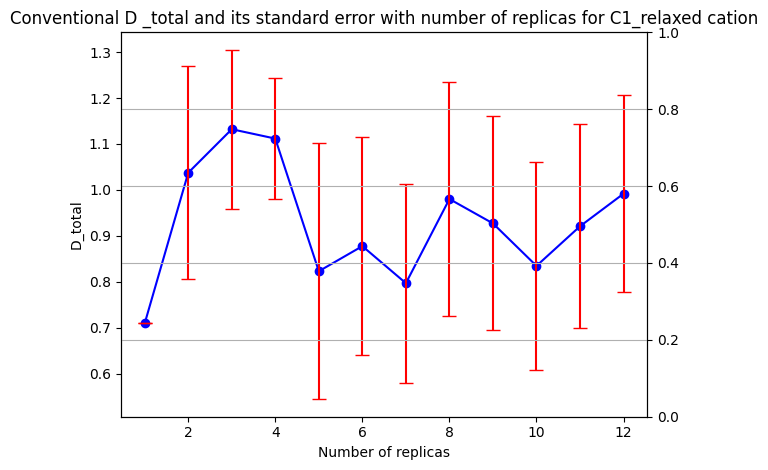

In [5]:
for i in cat:
    path=f'C:/shehani/postdoc_work/ML_Diffusion/cal_md/new_cals/{i}_rel/new/'
    df = pd.read_csv(f'{path}convD_{i}.csv')
    fig, ax1 = plt.subplots()
    
    # Plot Dmean on primary y-axis
    ax1.plot(df['nrep'], df['D_mean'], 'b-o', label='D_total')
    ax1.set_xlabel('Number of replicas')
    ax1.set_ylabel('D_total')
    ax1.tick_params(axis='y')
    ax1.errorbar(df['nrep'], df['D_mean'],yerr= df['D_se'], fmt='none', capsize=5, ecolor='red', ls='--')
   
    
    # Create secondary y-axis sharing the same x-axis
    ax2 = ax1.twinx()
    
    # Plot standard error on secondary y-axis
    #ax2.plot(df['nrep'], df['D_se'], 'r--s', label='Std_error')
    #ax2.set_ylabel('Std_error', color='r')
    #ax2.tick_params(axis='y', labelcolor='r')
    
    # Title and grid
    plt.title(f'Conventional D _total and its standard error with number of replicas for {i}_relaxed cation')
    fig.tight_layout()
    plt.grid(True)
    plt.show()

    #save the graph
    fig.savefig(f'{path}convD_{i}.png', dpi=150)

In [6]:
# n=15
# plt.figure()
# plt.plot(x_oh[n-1, :], label="x")
# plt.plot(y_oh[n-1, :], label="y")
# plt.xlabel('Number of steps (fs)')
# plt.ylabel('Position (Angstroms)')
# plt.title(f'Change of OH- with time for {cat}-relaxed over {steps} steps: rep{n}')
# plt.legend()
# plt.show()
# #plt.savefig(path +f'oh_id_{n}_{steps}.jpg')
# plt.savefig(path +f'oh_id_{n}_{steps}.jpg', dpi=200, bbox_inches='tight') 

In [7]:
# plt.plot(df['Time (ps)'], df['MSD (nm^2)'], marker='o')
# plt.xlabel('Time (ps)')
# plt.ylabel('MSD (nm²)')
# plt.title('Mean Squared Displacement over Time')
# plt.grid(True)
# plt.show()
            